In [1]:
import sys
import os

path = os.path.abspath(os.path.join(os.getcwd(), "../"))
sys.path.insert(0, path)
from tdaphantom.tdaphantom import Phantom

In [2]:
from ripser import ripser
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt
PRECOMPUTED_DIR = "./precomputed"

In [3]:
def _make_disk(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    pts = []
    while len(pts) < n:
        b = rng.uniform(-1, 1, (n * 4, 2))
        pts.append(b[np.linalg.norm(b, axis=1) <= 1.0])
    return np.vstack(pts)[:n]


def _make_circle(n=2000, noise=0.03, seed=1):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    pts   = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    return pts + rng.normal(0, noise, pts.shape)


def _make_torus(n=2000, R=5.0, r=3.0, seed=2):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    phi_list = []
    while len(phi_list) < n:
        phi_c = rng.uniform(0, 2 * np.pi, n * 2)
        w     = (R + r * np.cos(phi_c)) / (R + r)
        phi_list.append(phi_c[rng.uniform(0, 1, len(phi_c)) < w])
    phi = np.concatenate(phi_list)[:n]
    x   = (R + r * np.cos(phi)) * np.cos(theta)
    y   = (R + r * np.cos(phi)) * np.sin(theta)
    z   =  r * np.sin(phi)
    return np.stack([x, y, z], axis=1)



In [4]:

pc_disk   = _make_disk()
pc_circle = _make_circle()
pc_torus  = _make_torus()

phantom_disk   = Phantom(pc_disk)
phantom_circle = Phantom(pc_circle)
phantom_torus  = Phantom(pc_torus)

print(phantom_disk)
print(phantom_circle)
print(phantom_torus)

Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[], diagram_sizes={})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[], diagram_sizes={})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[], diagram_sizes={})


In [5]:
phantom_disk.calculate_dgms_from_point_cloud(k=1)
phantom_circle.calculate_dgms_from_point_cloud(k=1)
phantom_torus.calculate_dgms_from_point_cloud(k=1)


print(f"Disk   — H_1 bars: {len(phantom_disk.dgms[1])}")
print(f"Circle — H_1 bars: {len(phantom_circle.dgms[1])}")
print(f"Torus  — H_1 bars: {len(phantom_torus.dgms[1])}")

print(phantom_disk)
print(phantom_circle)
print(phantom_torus)

Disk   — H_1 bars: 519
Circle — H_1 bars: 391
Torus  — H_1 bars: 533
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 519})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 391})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 533})


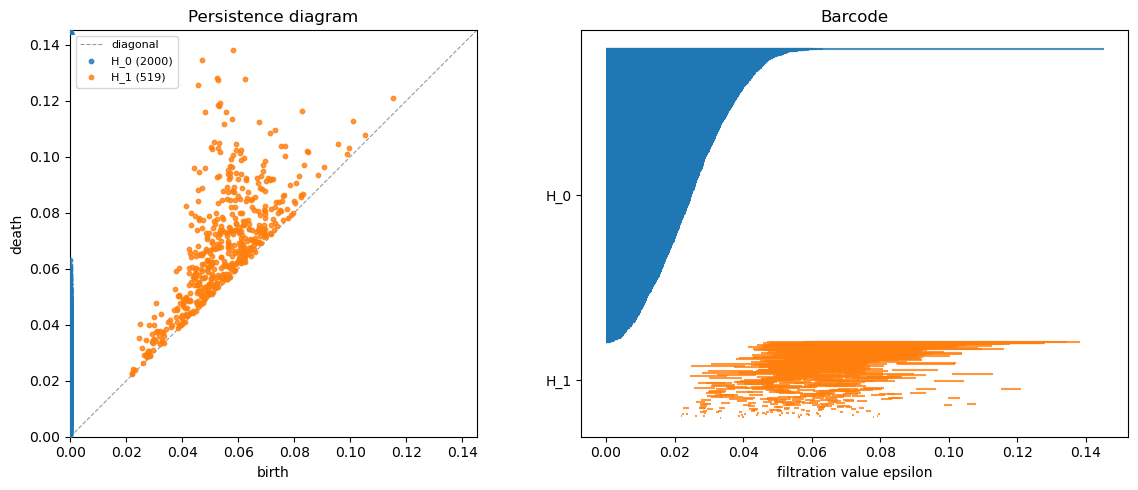

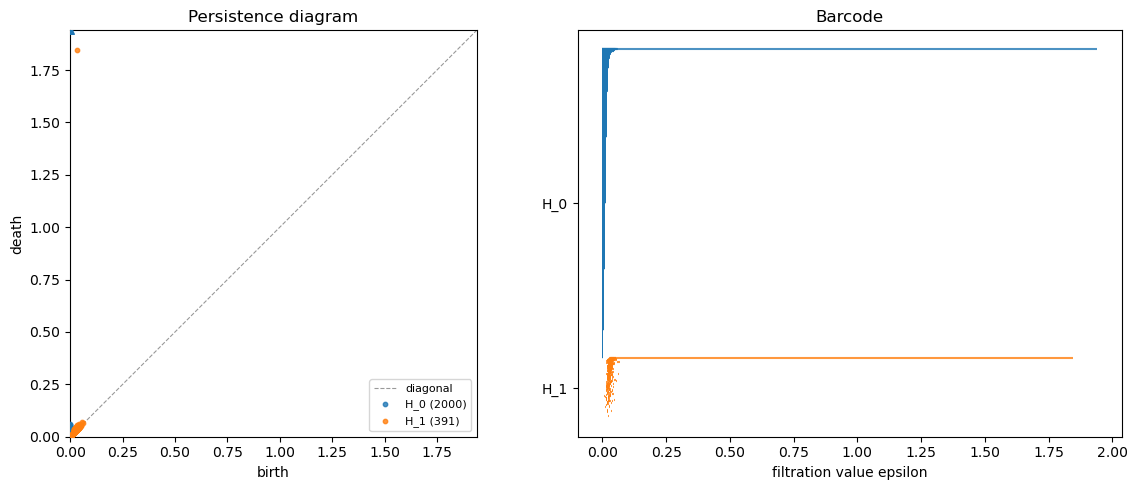

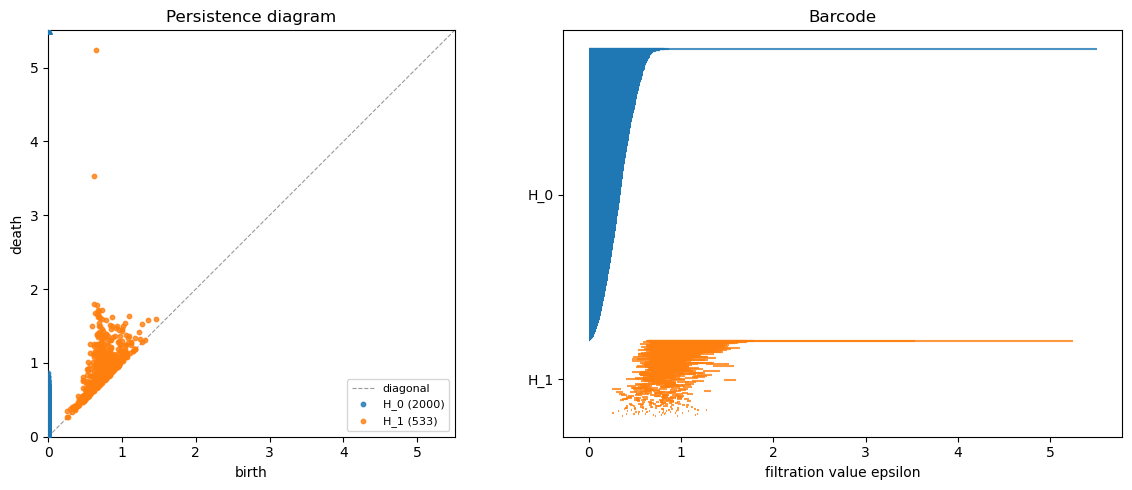

In [6]:
phantom_disk.display_dgms()
phantom_circle.display_dgms()
phantom_torus.display_dgms()

N: 100
0/100, 0.0%
1/100, 1.0%
2/100, 2.0%
3/100, 3.0%
4/100, 4.0%
5/100, 5.0%
6/100, 6.0%
7/100, 7.0%
8/100, 8.0%
9/100, 9.0%
10/100, 10.0%
11/100, 11.0%
12/100, 12.0%
13/100, 13.0%
14/100, 14.0%
15/100, 15.0%
16/100, 16.0%
17/100, 17.0%
18/100, 18.0%
19/100, 19.0%
20/100, 20.0%
21/100, 21.0%
22/100, 22.0%
23/100, 23.0%
24/100, 24.0%
25/100, 25.0%
26/100, 26.0%
27/100, 27.0%
28/100, 28.0%
29/100, 29.0%
30/100, 30.0%
31/100, 31.0%
32/100, 32.0%
33/100, 33.0%
34/100, 34.0%
35/100, 35.0%
36/100, 36.0%
37/100, 37.0%
38/100, 38.0%
39/100, 39.0%
40/100, 40.0%
41/100, 41.0%
42/100, 42.0%
43/100, 43.0%
44/100, 44.0%
45/100, 45.0%
46/100, 46.0%
47/100, 47.0%
48/100, 48.0%
49/100, 49.0%
50/100, 50.0%
51/100, 51.0%
52/100, 52.0%
53/100, 53.0%
54/100, 54.0%
55/100, 55.0%
56/100, 56.0%
57/100, 57.0%
58/100, 58.0%
59/100, 59.0%
60/100, 60.0%
61/100, 61.0%
62/100, 62.0%
63/100, 63.0%
64/100, 64.0%
65/100, 65.0%
66/100, 66.0%
67/100, 67.0%
68/100, 68.0%
69/100, 69.0%
70/100, 70.0%
71/100, 71.0%
72/10

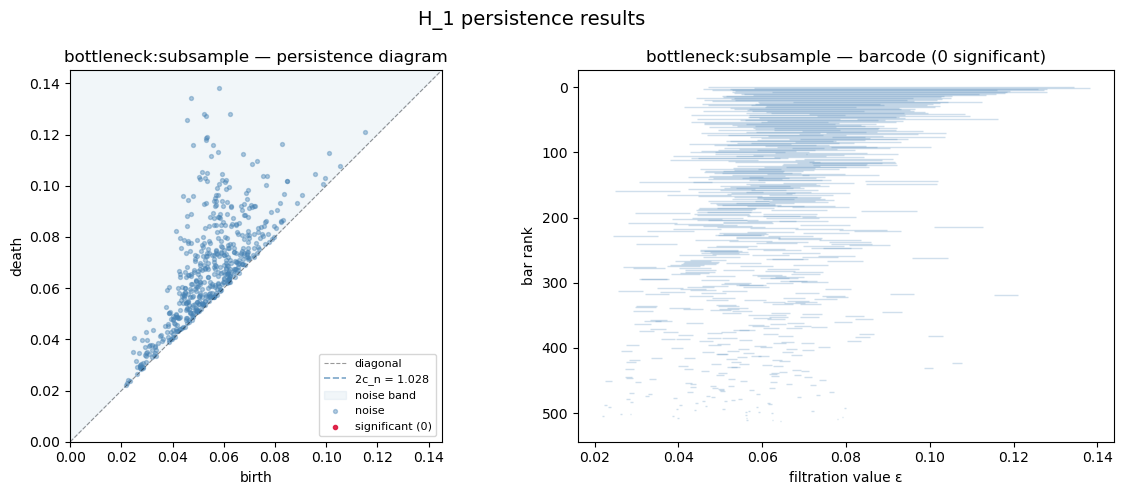

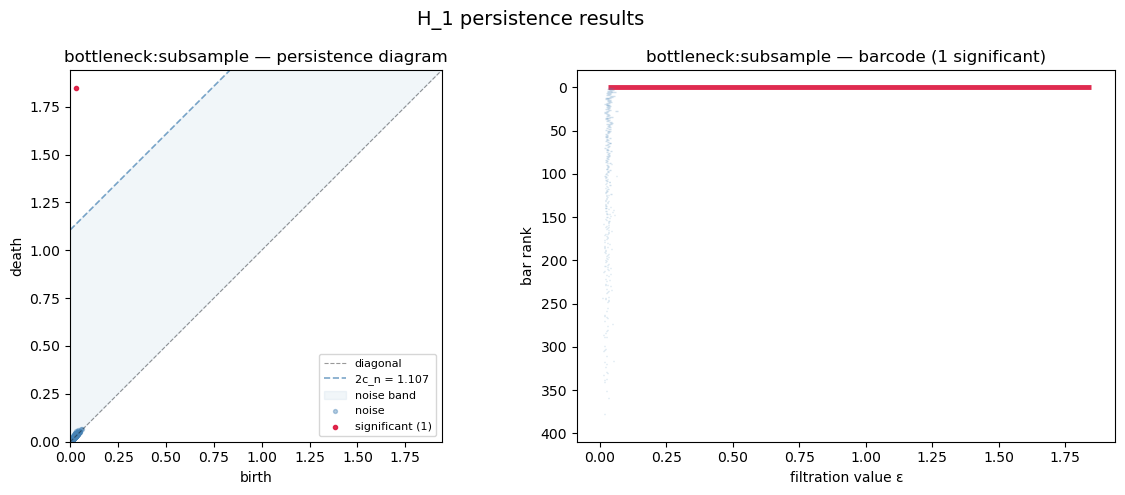

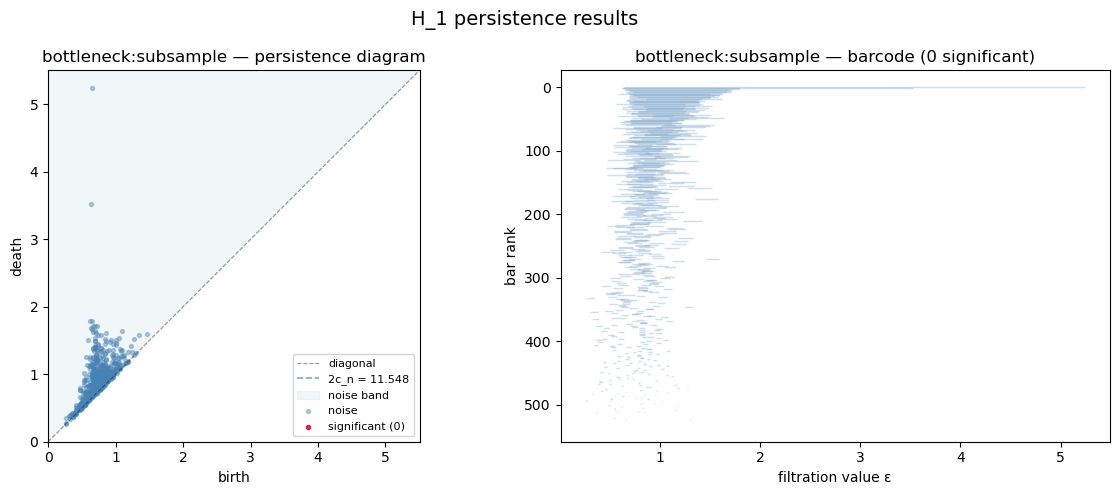

In [7]:
alpha = 0.01
method = ["bottleneck"]
results_disk   = phantom_disk.hypothesis_test(alpha=alpha,methods=method)
results_circle = phantom_circle.hypothesis_test(alpha=alpha,methods=method)
results_torus  = phantom_torus.hypothesis_test(alpha=alpha,methods=method)

phantom_disk.display_results()
phantom_circle.display_results()
phantom_torus.display_results()